In [1]:
#data format library
import h5py

#numpy
import numpy as np
# import pandas as pd
import numpy.ma as ma
%matplotlib inline
import matplotlib
import matplotlib.pyplot as plt
plt.rcParams["font.family"] = "sans-serif"
matplotlib.rcParams['pdf.fonttype'] = 42
# %matplotlib notebook
import sys
sys.path.append('./utils/')
import matplotlib.colors as pltcolors
import os
import copy
import partitioning_methods as cl
import coarse_graining as cgm
import operator_calculations as op_calc
import delay_embedding as embed
import stats
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
import time as tt
import scipy
import glob

np.random.seed(42)

In [69]:
Fig_path = '/flash/StephensU/Gautam/Figures/Comparing_MultiScale_Dynamics/FigS_bacteria_dynamics/'

In [4]:
path_to_filtered_data = '/flash/StephensU/Gautam/Multiscale_phenotypic_variation/Results/bacteria_all/'
f= h5py.File(path_to_filtered_data+'bacteria_all_data.h5','r')
print(f.keys())
bacteria_idx_all = np.array(f['MetaData/bacteria_idx_all'],dtype=int)
head_X_all = ma.asarray(f['X_all'],dtype=float)
dpsi_all = ma.array(f['dpsi_all'],dtype=float)
speeds_all = ma.array(f['speeds_all'],dtype=float)
lengths_all = np.array(f['MetaData/lengths_data'],dtype=int)
tbias = ma.array(f['tbias'],dtype=float)
runspeeds = ma.array(f['runspeeds'],dtype=float)
diffcoeff = ma.array(f['diffcoeff'],dtype=float)
yfp_cheb = ma.array(f['yfp_cheb'],dtype=float)
rfp_cher = ma.array(f['rfp_cher'],dtype=float)
f.close()

<KeysViewHDF5 ['MetaData', 'X_all', 'diffcoeff', 'dpsi_all', 'feats', 'meanruntime', 'msd_all', 'psi_all', 'rfp_cher', 'runspeeds', 'speeds_all', 'tbias', 'yfp_cheb']>


In [5]:
head_X_all[head_X_all==0] = ma.masked

dpsi_all[dpsi_all==0]=ma.masked
speeds_all[speeds_all==0] = ma.masked

tbias[tbias==-1] = ma.masked
diffcoeff[diffcoeff==0] = ma.masked
runspeeds[runspeeds==0] = ma.masked
rfp_cher[rfp_cher == 0] = ma.masked
yfp_cheb[yfp_cheb==0] = ma.masked

np.where(np.diff(bacteria_idx_all)<-100)
dataset_idx = np.zeros((bacteria_idx_all.shape[0],))
dataset_idx[np.where(np.diff(bacteria_idx_all)<-100)[0][0]+1:] = 1.

In [ ]:
## Entropy
seeds = np.arange(0,16)
path_to_filtered_data = '/flash/StephensU/Gautam/Multiscale_phenotypic_variation/Results/bacteria_all/Entropy/'
total_entropy = []
for s in seeds:
    f1 = h5py.File(path_to_filtered_data+'Entropy_seeds_delays_clusters_seed{}.h5'.format(s),'r')
    total_entropy.append(np.array(f1['entropies'],dtype=float))
    f1.close()

In [ ]:
total_entropy = np.vstack(total_entropy)

In [ ]:
K_range = np.arange(1,12,1)
n_clusters = np.arange(50,3000,200)

colors_ = plt.cm.viridis(np.linspace(0,1,K_range.shape[0]))
# colors_ = plt.cm.Reds(np.linspace(0,1,n_clusters.shape[0]))
# colors_ = plt.cm.viridis(np.linspace(0,1,10))

fig,ax = plt.subplots(1,1,figsize=(7,7))
for k in range(K_range.shape[0]):
    mean,cil,ciu = stats.bootstrap(total_entropy[:,k,:].squeeze(),n_times=1000)
    ax.errorbar(n_clusters,mean,[mean-cil,ciu-mean],marker='o', color=colors_[k], lw = 3, elinewidth=3, capsize=5)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
ax.axvline(1700,ls='--',c='r')
mean_seed,cil, ciu = stats.bootstrap(total_entropy[:,4,:], n_times=1000)
ax.plot(n_clusters,mean_seed, color='k',label= r'Delay $K = 5$', lw=3, alpha=1.0, zorder=10)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.savefig(Fig_path+'/Entropy.pdf')
plt.show()


In [6]:
path_to_filtered_data = '/flash/StephensU/Gautam/Multiscale_phenotypic_variation/Results/bacteria_all2/'
f = h5py.File(path_to_filtered_data + 'microstate_labels.h5','r')
print(f.keys())
lengths_all = np.array(f['MetaData/lengths_data'], dtype=int)
labels_recs = ma.array(f['microstate_labels'],dtype=int)
f.close()

<KeysViewHDF5 ['MetaData', 'microstate_labels']>


In [7]:
np.random.seed(42)
seeds = np.random.randint(0,10000,20)
delay_range = np.arange(1,20,1)
dt = 0.1
n_modes=20
sample_size = 450
to_mask = np.max(labels_recs.data)
labels_recs[labels_recs == to_mask] = ma.masked
labels_all= ma.concatenate(labels_recs,axis=0)
print(labels_recs.shape)

(6773, 2293)


In [21]:
def sampler(labels_recs, dataset_idx,lengths_all, window_size, to_mask, s):
    np.random.seed(s)
    sampled_labels = []
    for cond in np.unique(dataset_idx):
        cond_recs = np.where(dataset_idx == cond)[0]
        samples_ = to_mask*ma.ones((window_size+4,), dtype=int)
        labels_cond = labels_recs[cond_recs]
        rec_list = []
        for i, l in enumerate(lengths_all[cond_recs]):
            labels_cond[i,l-2:l] = ma.masked
            rec_list.append(labels_cond[i,:l])
        
        labels_ = ma.hstack(rec_list)
        start_pos = np.random.randint(0, len(labels_)-window_size)
        
        samples_[2:-2] = labels_[start_pos:start_pos+window_size]
        samples_[samples_==to_mask] = ma.masked
        sampled_labels.append(samples_)
    return sampled_labels

In [22]:
## Calculate implied timescales by sampling similar number of bouts from each condition

ts_traj_delay = ma.zeros((seeds.shape[0],len(delay_range),n_modes))
eigvals_shuffle = ma.zeros((seeds.shape[0],n_modes-1))
window_size = 1000000

for i,s in enumerate(seeds):
    print(s)
    labels_bootstrap = sampler(labels_recs, dataset_idx,lengths_all, window_size,to_mask,s)
    labels_ = ma.hstack(labels_bootstrap)
    nstates = ma.max(labels_) + 1
    segments = op_calc.segment_maskedArray(labels_)
    dtrajs = np.asarray([labels_[t0:tf] for t0,tf in segments],dtype=object)
    # idx1 = np.random.choice(np.arange(labels_recs.shape[0]), sample_size, replace=False)
    # labels_bootstrap = ma.concatenate([labels_recs[idx1]], axis=0)
    # labels_ = ma.hstack(labels_bootstrap)
    # nstates = ma.max(labels_) + 1
    # segments = op_calc.segment_maskedArray(labels_)

    # dtrajs = np.asarray([labels_[t0:tf] for t0,tf in segments],dtype=object)
    if ma.count(labels_)>20:
        for kd,delay in enumerate(delay_range):
            ts_traj_delay[i,kd,:] = op_calc.implied_tscale_shuffle(dtrajs,nstates,delay,dt,n_modes,reversible=True)
#     labels_shuffle = labels_[np.random.choice(np.arange(len(labels_)),len(labels_))]
#     P_shuffle = op_calc.transition_matrix(labels_shuffle,1)
    P_shuffle = op_calc.transition_matrix_shuffle(dtrajs,1)
    R_shuffle = op_calc.get_reversible_transition_matrix(P_shuffle)
    eigvals,eigvecs = op_calc.sorted_spectrum(R_shuffle,k=n_modes)
    sorted_indices = np.argsort(eigvals.real)[::-1]
    eigvals = eigvals[sorted_indices][1:].real
    eigvals[np.abs(eigvals-1)<1e-12] = np.nan
    eigvals[eigvals<1e-12] = np.nan
    eigvals_shuffle[i,:] = eigvals

7270
860
5390
5191
5734
6265
466
4426
5578
8322
1685
769
6949
2433
5311
5051
6420
1184
4555
3385


In [26]:
ts_traj_delay[ts_traj_delay==0] = ma.masked
eigvals_shuffle[eigvals_shuffle == 0] = ma.masked 

## Use if sampling similar number of bouts from each condition

ts_traj_delay_total = ts_traj_delay
eigvals_shuffle_total = eigvals_shuffle
print(ts_traj_delay_total.shape)
print(eigvals_shuffle_total.shape)

(20, 19, 20)
(20, 19)


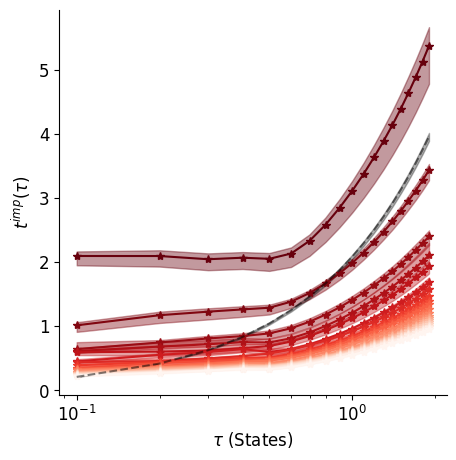

In [27]:
# Fig S2a - time scales for tau
colors_ = plt.cm.Reds_r(np.linspace(0,1,n_modes))

fig, ax = plt.subplots(1,1,figsize=(5,5))
for mode in range(n_modes):
    mean = ma.mean(ts_traj_delay_total[:,:,mode],axis=0)
    cil = np.nanpercentile(ts_traj_delay_total[:,:,mode],2.5,axis=0)
    ciu = np.nanpercentile(ts_traj_delay_total[:,:,mode],97.5,axis=0)
    # mean,cil,ciu=stats.bootstrap(ts_traj_delay_total[:,:,mode].squeeze(),median=False,n_times=1000)
    ax.plot(delay_range*dt,mean,c=colors_[mode], marker='*')
    # ax.errorbar(delay_range*dt, mean,[mean-cil, ciu - mean], marker='o', capsize=4, color = colors_[mode])
    ax.fill_between(delay_range*dt, cil, ciu, color=colors_[mode], alpha=0.4)

tscales_shuffle = np.array([-d*dt/np.log(eigvals_shuffle_total[:,0]) for d in delay_range])
mean,cil,ciu=stats.bootstrap((tscales_shuffle.T),n_times=1000)

ax.plot(delay_range*dt,mean,c='k',alpha=.5,ls='--', label='Noise Floor')
ax.fill_between(delay_range*dt,cil,ciu,color='k',alpha=.3)
# ax.legend(fontsize = 30)
ax.set_xlabel(r'$\tau$ (States)',fontsize=12)
ax.set_ylabel(r'$t^{imp} (\tau)$',fontsize=12)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.set_xscale('log')
# ax.set_ylim(0,50)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.savefig(Fig_path+'/t_imp_tau.pdf')
plt.show()

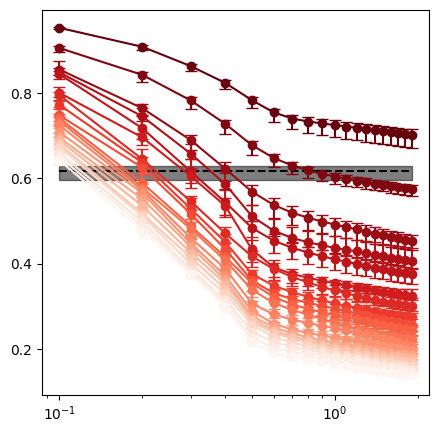

In [28]:
fig, ax = plt.subplots(1,1,figsize=(5,5))
for mode in range(n_modes):
    mean = ma.mean(ts_traj_delay_total[:,:,mode],axis=0)
    cil = np.nanpercentile(ts_traj_delay_total[:,:,mode],2.5,axis=0)
    ciu = np.nanpercentile(ts_traj_delay_total[:,:,mode],97.5,axis=0)
    # ax.plot(delay_range*dt,np.exp((-delay_range*dt)/mean),c=colors_[mode], marker='*')
    ax.errorbar(delay_range*dt, np.exp((-delay_range*dt)/mean),[np.exp((-delay_range*dt)/mean)-np.exp((-delay_range*dt)/cil), np.exp((-delay_range*dt)/ciu) - np.exp((-delay_range*dt)/mean)], 
                marker='o', capsize=4, color = colors_[mode])
# mean,cil,ciu=stats.bootstrap((eigvals_shuffle_total[:,0]),n_times=1000)
mean = ma.mean(eigvals_shuffle_total[:,0])
cil = np.nanpercentile(eigvals_shuffle_total[:,0],2.5,axis=0)
ciu = np.nanpercentile(eigvals_shuffle_total[:,0],97.5,axis=0)
ax.plot(delay_range*dt,mean*np.ones((len(delay_range))),ls='--',c='k')
ax.fill_between(delay_range*dt,cil*np.ones((len(delay_range))),ciu*np.ones((len(delay_range))),color='k', alpha=0.5)
# plt.xlim(0,6)
# plt.yscale('log')
ax.set_xscale('log')
plt.savefig(Fig_path + 'eigvals_tau.pdf')

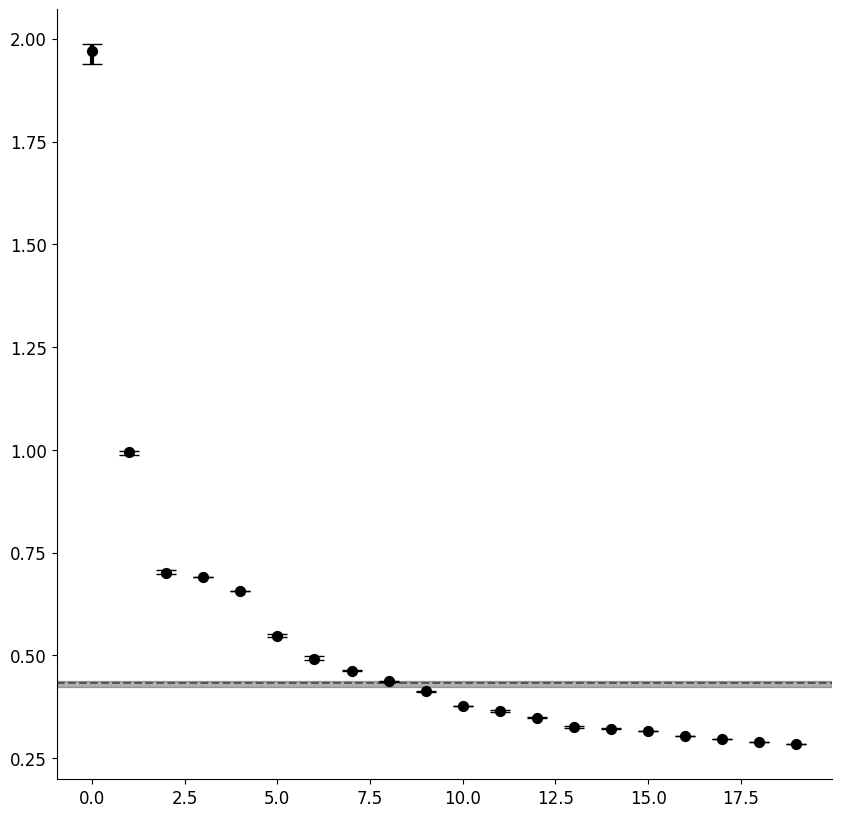

In [142]:
# Fig 2a 
fig, ax = plt.subplots(1,1,figsize=(10,10))

tau = 2

tscales_shuffle = np.array([-d*dt/np.log(eigvals_shuffle_total[:,0]) for d in delay_range])
mean,cil,ciu=stats.bootstrap((tscales_shuffle.T),n_times=1000)

ts_traj_delay1 = ts_traj_delay_total[:,tau-1,:]
mean,cil,ciu=stats.bootstrap(ts_traj_delay1[:,:],median=False,n_times=1000)
ax.scatter(np.arange(n_modes),mean,c='k', s =50)
ax.errorbar(np.arange(n_modes), mean,[mean-cil, ciu - mean], fmt='.', capsize=7, elinewidth=3, color = 'k')

mean,cil,ciu=stats.bootstrap((tscales_shuffle.T),n_times=1000)
ax.axhline(mean[tau-1],c='k',alpha=.5,ls='--', label='Noise Floor')
ax.axhspan(cil[tau-1],ciu[tau-1],color='k',alpha=.3)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
# plt.savefig(Fig_path+'/t_imp_tau_2.pdf')

In [8]:
P_ensemble = np.load(path_to_filtered_data + 'P_ensemble.npy')

In [9]:
import deeptime.markov.tools.estimation as msm_estimation
from scipy.sparse import diags,identity,coo_matrix, csr_matrix

delay = 2
print(delay)

# segments = op_calc.segment_maskedArray(labels_all)
# dtrajs = np.asarray([labels_all[t0:tf] for t0,tf in segments])
# # print(len(dtrajs))

# lcs_ensemble,P_ensemble = op_calc.transition_matrix(dtrajs,delay,return_connected=True)
P_ensemble = csr_matrix(P_ensemble)
lcs_ensemble = msm_estimation.largest_connected_set(P_ensemble)
inv_measure = op_calc.stationary_distribution(P_ensemble)
final_labels = op_calc.get_connected_labels(labels_all,lcs_ensemble)
R = op_calc.get_reversible_transition_matrix(P_ensemble)
eigvals,eigvecs = op_calc.sorted_spectrum(R,k=10,seed=123) 
sorted_indices = np.argsort(eigvals.real)[::-1]
eigvals = eigvals[sorted_indices][1:].real
eigvals[np.abs(eigvals-1)<1e-12] = np.nan
eigvals[eigvals<1e-12] = np.nan
t_imp =  -(delay*dt)/np.log(np.abs(eigvals))
eigfunctions = eigvecs.real/np.linalg.norm(eigvecs.real,axis=0)
eigfunctions_traj = ma.array(eigfunctions)[final_labels,:]
eigfunctions_traj[final_labels.mask] = ma.masked

2


In [10]:
phi1 = eigfunctions[:,1]
phi2 = eigfunctions[:,2]
phi3 = eigfunctions[:,3]
phi4 = eigfunctions[:,4]
phi5 = eigfunctions[:,5]
phi6 = eigfunctions[:,6]

In [64]:
c_range_phi,_,_,split_idx,_ = op_calc.optimal_partition(phi1,inv_measure,P_ensemble,return_rho=True)

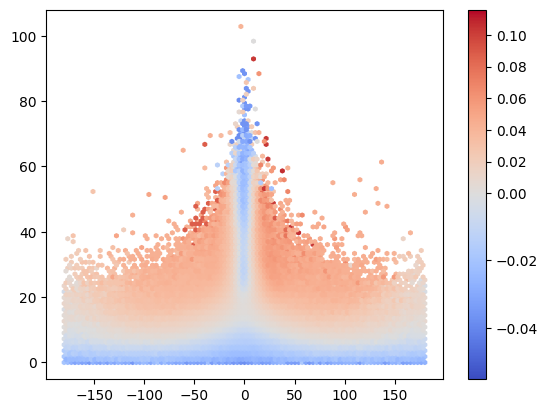

In [48]:
# random_sample = np.random.choice(np.arange(len(ma.hstack(speeds_all))),100000,replace=False)
divnorm = pltcolors.TwoSlopeNorm(vmin=ma.min(phi1), vcenter=c_range_phi[split_idx], vmax=ma.max(phi1))
plt.hexbin(ma.hstack(dpsi_all)*(180/np.pi),ma.hstack(speeds_all),C=eigfunctions_traj[:,4],cmap='coolwarm',norm=divnorm)
plt.colorbar()
# plt.savefig(Fig_path+'/speed_phi_phi4.pdf')
plt.show()

In [11]:
f =  h5py.File(path_to_filtered_data + '/cg_labels_tree_minrho.h5')
labels_tree = np.array(f['labels_tree'],dtype=int)
print(f.keys())
f.close()

<KeysViewHDF5 ['labels_tree']>


In [13]:
ha = labels_tree[0]

cluster_traj_all = ma.copy(final_labels)
cluster_traj_all[~final_labels.mask] = ma.array(ha)[final_labels[~final_labels.mask]]
cluster_traj_all[final_labels.mask] = ma.masked

2


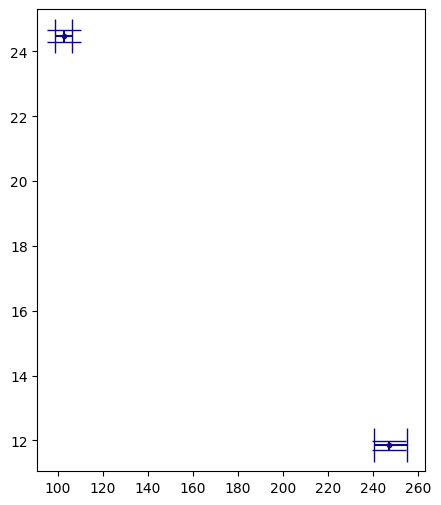

3


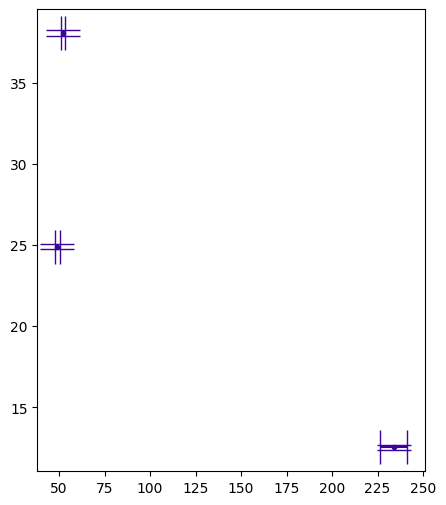

4


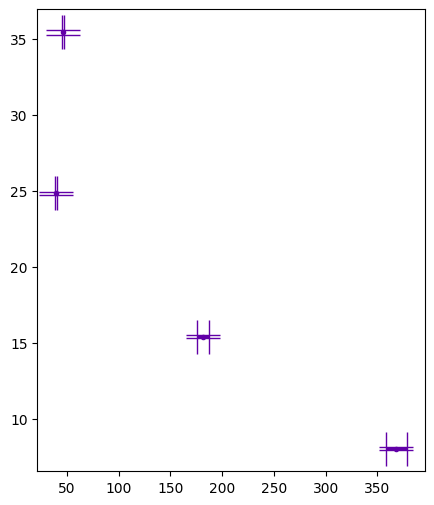

5


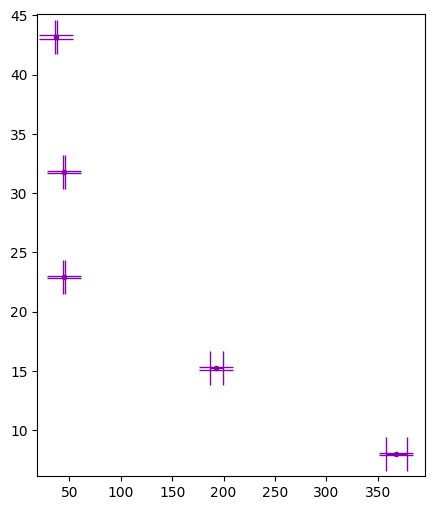

6


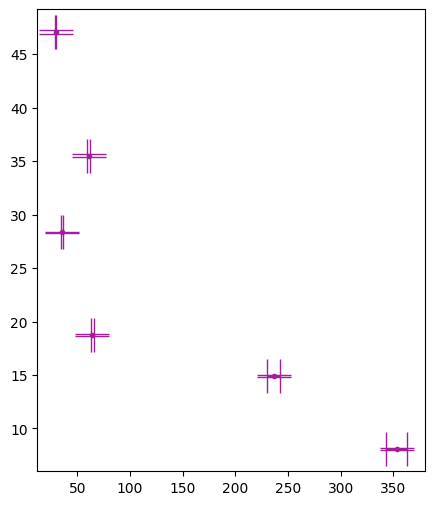

In [77]:
colors_ = plt.cm.plasma(np.linspace(0,.8,10))

for i,q in enumerate(np.arange(2,8)):
    plt.figure(figsize=(5,6))
    print(q)

    ha = labels_tree[i]

    cluster_traj_all = ma.copy(final_labels)
    cluster_traj_all[~final_labels.mask] = ma.array(ha)[final_labels[~final_labels.mask]]
    cluster_traj_all[final_labels.mask] = ma.masked
    
    mxs = []
    cilxs = []
    ciuxs = []

    mys = []
    cilys = []
    ciuys = []
    
    for c in np.unique(ha):
        idx = np.where(cluster_traj_all == c)[0]
        m,cil,ciu = bootstrap((ma.hstack(ma.abs(dpsi_all)*180/np.pi)/dt)[idx],n_samples=5000,n_times=100)
        mxs.append(m)
        cilxs.append(cil[0])
        ciuxs.append(ciu[0])
        
        m,cil,ciu = bootstrap(ma.hstack(speeds_all)[idx],n_samples=5000,n_times=100)
        mys.append(m)
        cilys.append(cil[0])
        ciuys.append(ciu[0])
    plt.errorbar(mxs,mys,xerr=[np.array(mxs)-np.array(cilxs),np.array(ciuxs)-np.array(mxs)],
                 yerr= [np.array(mys)-np.array(cilys),np.array(ciuys)-np.array(mys)],
                 capsize=12,ls='None',color = colors_[i],fmt='.')
    # plt.xlim(0,400)
    # plt.ylim(0,60)
    plt.savefig(Fig_path+'dpsi_speed_q{}.pdf'.format(q))
    plt.show()
# ax.yaxis.set_inverted(True)
plt.show()